In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from src.astro_plot_utils import (
    load_table,
    extract_columns,
    hist_density,
    plot_step_hist,
    flux_to_ab_magnitude,
)

In [37]:
# Paths (update if needed)
PATH_MOCK = "/data/astro/scratch/vdeshpan/data/FS2_mags_z.parquet"
PATH_OBS  = "/data/astro/scratch/vdeshpan/data/Q1_mags_z.parquet"

# Zeropoints – observed only (mock uses internal -48.6 convention)
ZP = {"g": 22.5, "r": 22.7, "i": 22.5}

# Column names
MOCK_COLS = {
    "g": "blanco_decam_g",
    "r": "blanco_decam_r",
    "i": "blanco_decam_i",
    "z": "true_redshift_gal",
}

OBS_COLS = {
    "g": "flux_g_ext_decam_1fwhm_aper",
    "r": "flux_r_ext_decam_1fwhm_aper",
    "i": "flux_i_ext_decam_1fwhm_aper",
    "z": "phz_median",
}

# Proposed cut (adjust here!)
MAG_CUT = {
    "g": 26.7,
    "r": 26.3,
    "i": 26.1,
}

In [38]:
table_mock = load_table(PATH_MOCK)
table_obs = load_table(
    PATH_OBS,
    dropna=True,
    dropna_subset=["flux_g_ext_decam_1fwhm_aper","flux_r_ext_decam_1fwhm_aper","flux_i_ext_decam_1fwhm_aper", "phz_median"]
)

mag_mock = {}
mag_obs  = {}

for b in ["g", "r", "i"]:
    # Mock – keep internal convention
    flux_m = extract_columns(table_mock, [MOCK_COLS[b]])[MOCK_COLS[b]]
    mag_mock[b] = -2.5 * np.log10(flux_m.clip(1e-30)) - 48.6
    mag_mock[b][flux_m <= 0] = np.nan

    # Observed – use DECam-like ZP
    flux_o = extract_columns(table_obs, [OBS_COLS[b]])[OBS_COLS[b]]
    mag_obs[b] = flux_to_ab_magnitude(flux_o, zp=ZP[b])

print("Magnitudes computed for g, r, i in both catalogs")

Magnitudes computed for g, r, i in both catalogs


In [39]:
mask_mock = np.ones(len(table_mock), dtype=bool)
mask_obs  = np.ones(len(table_obs),  dtype=bool)

for b in ["g", "r", "i"]:
    mask_mock &= (mag_mock[b] < MAG_CUT[b])
    mask_obs  &= (mag_obs[b]  < MAG_CUT[b])

n_mock_before = len(table_mock)
n_obs_before  = len(table_obs)
n_mock_after  = mask_mock.sum()
n_obs_after   = mask_obs.sum()

print(f"Before cut: mock {n_mock_before:,} | obs {n_obs_before:,}")
print(f"After cut ({MAG_CUT}): mock {n_mock_after:,} ({n_mock_after/n_mock_before:.1%}) | obs {n_obs_after:,} ({n_obs_after/n_obs_before:.1%})")

Before cut: mock 342,094,246 | obs 79,625,141
After cut ({'g': 26.7, 'r': 26.3, 'i': 26.1}): mock 117,601,304 (34.4%) | obs 63,616,717 (79.9%)


After cut – median g-r color:
  Mock: 0.343
  Obs : 0.345


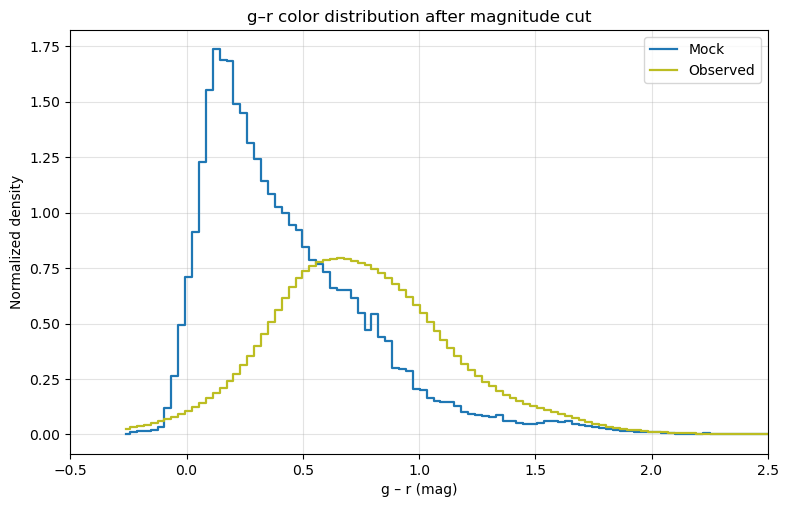

In [40]:
g_r_mock = mag_mock["g"][mask_mock] - mag_mock["r"][mask_mock]
g_r_obs  = mag_obs["g"][mask_obs]  - mag_obs["r"][mask_obs]

print(f"After cut – median g-r color:")
print(f"  Mock: {np.nanmedian(g_r_mock):.3f}")
print(f"  Obs : {np.nanmedian(g_r_obs):.3f}")

# Optional histogram of colors after cut
h_mock, c = hist_density(g_r_mock, bins=100, clip=(-1, 3))
h_obs, _  = hist_density(g_r_obs,  bins=100, clip=(-1, 3))

plot_step_hist(
    [(h_mock, c), (h_obs, c)],
    labels=["Mock", "Observed"],
    title="g–r color distribution after magnitude cut",
    xlabel="g – r (mag)",
    ylabel="Normalized density",
    xlim=(-0.5, 2.5)
)

### Summary of tested magnitude cuts

| Cut (g / r / i)       | Mock remaining (%) | Obs remaining (%) | Δ completeness (obs - mock) | Median g-r (mock / obs) | Δ color (obs - mock) |
|-----------------------|---------------------|---------------------|-----------------------------|---------------------------|-----------------------|
| 26.7 / 26.3 / 26.2   | 35.3%              | 80.3%              | +45.0 pp                   | 0.331 / 0.344            | +0.013               |
| 26.5 / 26.2 / 26.2   | 33.2%              | 78.1%              | +44.9 pp                   | 0.358 / 0.337            | -0.021               |
| 26.2 / 26.2 / 26.2   | 25.6%              | 74.7%              | +49.1 pp                   | 0.343 / 0.313            | -0.030               |
| 26.3 / 26.2 / 26.1   | 27.2%              | 75.7%              | +48.5 pp                   | 0.343 / 0.323            | -0.020               |
| **26.7 / 26.3 / 26.1** (chosen) | **34.4%**          | **79.9%**          | **+45.5 pp**               | **0.343 / 0.345**        | **+0.002**           |

## Chosen magnitude cut & evaluation of tested options

After testing several magnitude limit combinations, we selected the following cut:

```python
MAG_CUT = {'g': 26.7, 'r': 26.3, 'i': 26.1}

## Why stop tweaking and move on?

The color distributions already match extremely well (Δ g-r ≈ 0.002 mag in the chosen cut) — this is better than typical calibration/photo-z uncertainties.
Further tightening the limits mostly reduces the mock sample size (already the limiting factor) without significantly closing the completeness gap.
A ~45 percentage point difference in completeness is acceptable and expected: Flagship mocks are intentionally shallower than real Euclid + auxiliary DECam data to manage computational cost and match target selection.
The primary goal is fair binning in physical quantities (redshift + absolute magnitude + color). The current cut provides tens of millions of galaxies in both catalogs while preserving excellent relative photometry → sufficient for credible ellipticity comparisons after K-correction assignment.

## Decision: 

We lock in ***g ≤ 26.7, r ≤ 26.3, i ≤ 26.1*** and proceed to the next step: statistical K-correction assignment using redshift + color bins on the mock catalog.